In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg  # για την προαιρετική ανάγνωση δικής σας εικόνας


## Άσκηση - Εξομάλυνση εικόνας με σταθμισμένο φίλτρο κυλιόμενης μέσης τιμής

Στην άσκηση $\texttt{Ex-LinearAndNonlinearImageDenoising}$ είδαμε ότι το απλό φίλτρο κυλιόμενης μέσης τιμής (Moving Average) δίνει σε **όλα** τα δείγματα το ίδιο βάρος. Ένα *σταθμισμένο* φίλτρο δίνει μεγαλύτερο βάρος στο κεντρικό δείγμα και μικρότερο στους γείτονες, προσεγγίζοντας μια **Gaussian** καμπύλη. 

Το πιο γνωστό τέτοιο φίλτρο τριών σημείων είναι το **διωνυμικό** με κρουστική απόκριση $\tfrac{1}{4}[1,\,2,\,1]$:

$$ y[n] = \tfrac{1}{4}x[n+1] + \tfrac{1}{2}x[n] + \tfrac{1}{4}x[n-1] = \frac{1}{4}\sum_{k=-1}^{1} w_k\,x[n-k], \quad w=[1,2,1] \tag{1}$$

Πρόκειται πάλι για ένα **σύστημα διακριτού χρόνου** (εξίσωση διαφορών), γραμμικό και χρονικά αμετάβλητο (LTI). 

**Διαχωρισιμότητα (separability).** 

Αν εφαρμόσουμε τη Σχέση (1) πρώτα στις γραμμές και μετά στις στήλες, το αποτέλεσμα ισοδυναμεί με ένα δισδιάστατο φίλτρο με πυρήνα

$$ \frac{1}{16}\begin{bmatrix}1&2&1\\2&4&2\\1&2&1\end{bmatrix} = \frac{1}{4}\!\begin{bmatrix}1\\2\\1\end{bmatrix}\cdot\frac{1}{4}\begin{bmatrix}1&2&1\end{bmatrix} \tag{3}$$

δηλαδή τη γνωστή προσέγγιση **2D Gaussian**. Έτσι ένα ακριβό 2D φιλτράρισμα ανάγεται σε δύο φθηνά 1D περάσματα.

### i. Δημιουργία καθαρής και θορυβώδους εικόνας

Παρακάτω φτιάχνουμε μια συνθετική εικόνα (καθαρή) και της προσθέτουμε **Gaussian θόρυβο**, που μοντελοποιεί π.χ. θερμικό θόρυβο αισθητήρα.

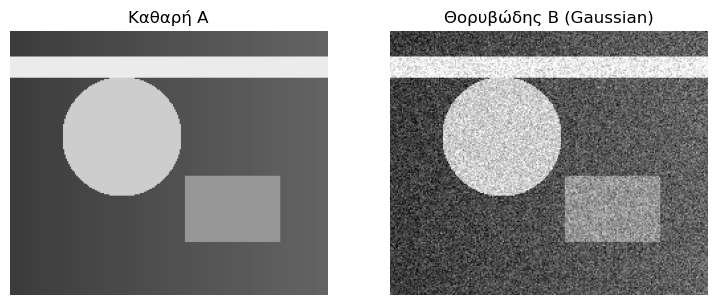

In [ ]:
def make_test_image(M=200, N=240):
    """Δημιουργεί μια συνθετική grayscale εικόνα (τιμές 0-255) με ομαλό
    background, φωτεινό δίσκο, ορθογώνιο και λωρίδες (ακμές)."""
    yy, xx = np.mgrid[0:M, 0:N]
    A = 60.0 + 40.0*(xx/N)                       # ομαλή ράμπα φωτεινότητας
    A[(xx-0.35*N)**2 + (yy-0.40*M)**2 < 45**2] = 205   # φωτεινός δίσκος
    A[int(0.55*M):int(0.80*M), int(0.55*N):int(0.85*N)] = 150  # ορθογώνιο
    A[int(0.10*M):int(0.18*M), :] = 235          # οριζόντια λωρίδα
    return np.clip(A, 0, 255)

def add_gaussian_noise(A, sigma=25.0, seed=0):
    rng = np.random.default_rng(seed)
    return np.clip(A + rng.normal(0, sigma, A.shape), 0, 255)

A = make_test_image()          # καθαρή εικόνα
B = add_gaussian_noise(A, sigma=25)   # θορυβώδης είσοδος

# Προαιρετικά: για δική σας εικόνα, αντικαταστήστε με
# A = mpimg.imread('./files/MyImage.tif').astype(float)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(A, cmap='gray', vmin=0, vmax=255); ax[0].set_title('Καθαρή A'); ax[0].axis('off')
ax[1].imshow(B, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Θορυβώδης B (Gaussian)'); ax[1].axis('off')
plt.show()

### ii. Φιλτράρισμα κατά γραμμές

Θεωρούμε κάθε γραμμή της εικόνας ως ένα 1D σήμα $x[n]$ και το διατρέχουμε σε τριάδες. Δείτε τον κώδικα παρακάτω. Γιατί ο εσωτερικός βρόχος πάει από `1` έως `N-2` και όχι από `0` έως `N-1`;

    M, N = B.shape
    C = np.zeros((M, N))
    w = np.array([1., 2., 1.]) / 4.0        # βάρη διωνυμικού πυρήνα
    for i in range(M):            # για κάθε γραμμή
        for j in range(1, N-1):   # γιατί όχι 0..N-1;
            x = B[i, j-1:j+2]     # τριάδα δειγμάτων
            y = #############     # Σχέση (1)
            C[i, j] = y

**Φιλτράρισμα κατά γραμμές**

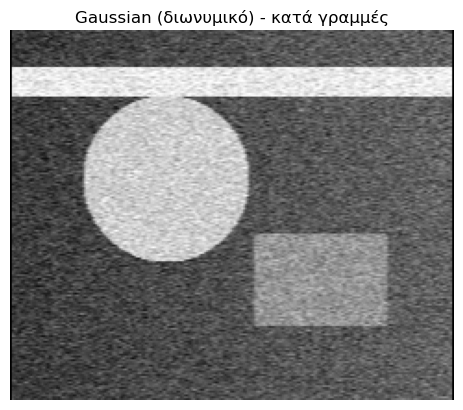

In [3]:
M, N = B.shape
C = np.zeros((M, N))
w = np.array([1., 2., 1.]) / 4.0

for i in range(M):                 # επεξεργασία γραμμής B[i, :]
    for j in range(1, N-1):        # άκρα: δεν υπάρχει πλήρης τριάδα
        x = B[i, j-1:j+2]
        C[i, j] = np.sum(w * x)

C = np.clip(C, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(C, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('Gaussian (διωνυμικό) - κατά γραμμές')
plt.axis('off')
plt.show()

**Φιλτράρισμα κατά στήλες** (προσέξτε την αντιστροφή των δεικτών στους βρόχους)

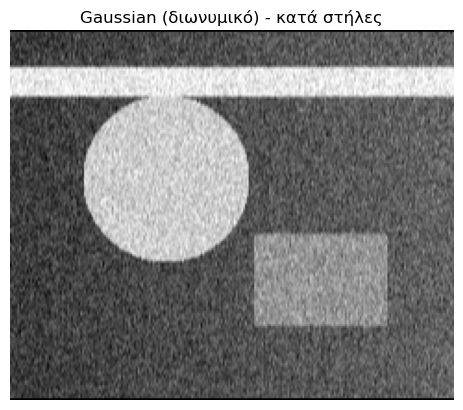

In [4]:
C = np.zeros((M, N))
w = np.array([1., 2., 1.]) / 4.0

for j in range(N):                 # επεξεργασία στήλης B[:, j]
    for i in range(1, M-1):
        x = B[i-1:i+2, j]
        C[i, j] = np.sum(w * x)

C = np.clip(C, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(C, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('Gaussian (διωνυμικό) - κατά στήλες')
plt.axis('off')
plt.show()

### iii. Φιλτράρισμα σε γραμμές **και** στήλες

Εφαρμόζουμε το φίλτρο πρώτα στις γραμμές και στη συνέχεια στο αποτέλεσμα κατά στήλες. Σύμφωνα με τη Σχέση (3) αυτό ισοδυναμεί με ένα 2D Gaussian φίλτρο.

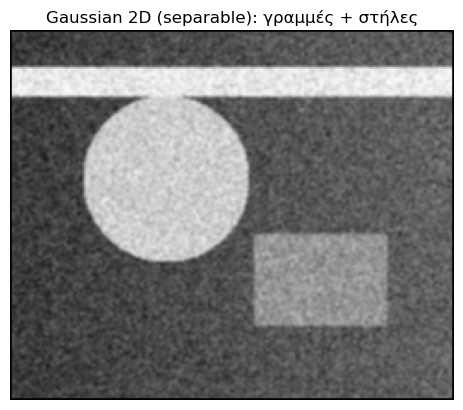

In [5]:
# Πέρασμα 1: γραμμές  ->  C
C = np.zeros((M, N)); D = np.zeros((M, N))
w = np.array([1., 2., 1.]) / 4.0
for i in range(M):
    for j in range(1, N-1):
        C[i, j] = np.sum(w * B[i, j-1:j+2])

# Πέρασμα 2: στήλες πάνω στο C  ->  D
for j in range(N):
    for i in range(1, M-1):
        D[i, j] = np.sum(w * C[i-1:i+2, j])

D = np.clip(D, 0, 255).astype(np.uint8)
plt.figure()
plt.imshow(D, cmap=plt.get_cmap('gray'), vmin=0, vmax=255)
plt.title('Gaussian 2D (separable): γραμμές + στήλες')
plt.axis('off')
plt.show()

### Παρατηρήσεις

Το σταθμισμένο (διωνυμικό) φίλτρο μειώνει αισθητά τον Gaussian θόρυβο διατηρώντας καλύτερα το κεντρικό δείγμα απ' ό,τι το απλό MA· έτσι η εικόνα θολώνει λιγότερο για την ίδια υποστήριξη τριών σημείων. Το φιλτράρισμα **μόνο** κατά γραμμές αφήνει κατακόρυφο θόρυβο (και αντίστροφα για τις στήλες), αφού η εξομάλυνση γίνεται μόνο σε μία διάσταση. Η **διαχωρίσιμη** εφαρμογή (γραμμές + στήλες) δίνει σαφώς καλύτερο αποτέλεσμα — ισοδυναμεί με 2D Gaussian — με κόστος ελαφράς γενικής θόλωσης των ακμών, κάτι αναπόφευκτο για κάθε γραμμικό χαμηλοπερατό φίλτρο. 

Σε αντίθεση με το median φίλτρο (φίλτρο μεσαίας τιμής), το γραμμικό αυτό φίλτρο **δεν** αντιμετωπίζει καλά τον salt & pepper θόρυβο, γιατί "απλώνει" τις ακραίες τιμές αντί να τις απορρίπτει.

---
---